# 15 · Vecinas de la misma hora: resultados frente al V4

Protocolo: `docs/protocolo_contemporaneo_v1.md` (`v4c_multianual_33_p95cal2023_v1`).
Compara tres detectores con las mismas etapas, umbral p95 de 2023 y ataques:

| Familia | Qué ve para estimar la hora t | Modelo |
|---|---|---|
| **V4** (referencia, ya entrenado) | vecinas de t−24 a **t−1** | LSTM |
| **lstm_t** | vecinas de t−23 a **t** (incluye la misma hora) | LSTM idéntico |
| **lineal_t** | vecinas **sólo en t** | regresión ridge (línea base simple) |

**Este libro no entrena ni calcula nada**: lee lo que produce el script.

## Cómo ejecutar (en una terminal, desde la raíz del repo)

```bash
# todo de corrido, en segundo plano (≈40–60 min); se puede cerrar la terminal
nohup .venv/bin/python experiments/contemporaneo/ejecutar.py > /dev/null 2>&1 &

# ver el avance
tail -f results/contemporaneo_v1/ejecucion.log
```

Si se interrumpe, vuelve a lanzar el mismo comando: lo ya guardado se salta. Etapas, en
orden: entrenar (`lstm_t` y `lineal_t`, 31 estaciones cada una) → verificar
(reentrena CCA y exige resultados idénticos; si no, se detiene) → evaluar (un mensaje,
como el notebook 13) → simultáneo (mismo bit en todas las estaciones a la vez).

**Qué significa el atacante simultáneo:** en el 5 % de las horas, el atacante voltea el
mismo bit en **todas** las estaciones a la vez. Es posible porque está entre el Network
Server y el Application Server y ve todo el tráfico. Es la prueba de fuego para la variante
contemporánea, que confía en que las vecinas digan la verdad en esa misma hora.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')
from src.detect import multianual as m

C1 = RAIZ / 'results/contemporaneo_v1'
V4 = RAIZ / 'results/lstm_v4_multianual_v1'
IMG = RAIZ / 'docs/img/contemporaneo_v1'
IMG.mkdir(parents=True, exist_ok=True)
FAM = {'v4': V4, 'lstm_t': C1 / 'lstm_t', 'lineal_t': C1 / 'lineal_t'}
COLOR = {'v4': '#52514e', 'lstm_t': '#2a78d6', 'lineal_t': '#eb6834'}
ETIQ = {'v4': 'V4 (hasta t−1)', 'lstm_t': 'LSTM con hora t', 'lineal_t': 'lineal con hora t'}
pd.set_option('display.width', 220)
plt.rcParams.update({'axes.grid': True, 'grid.color': '#e6e5e0', 'axes.spines.top': False,
                     'axes.spines.right': False, 'lines.linewidth': 2, 'legend.frameon': False,
                     'axes.titleweight': 'bold', 'axes.titlesize': 11})
cob = pd.read_csv(V4 / 'cobertura_etapas.csv')
CLASES = cob.drop_duplicates('objetivo').set_index('objetivo')['clasificacion']

def leer(fam, archivo):
    f = FAM[fam] / archivo
    return pd.read_csv(f) if f.exists() else None

def disponibles(archivo):
    return [f for f in FAM if (FAM[f] / archivo).exists()]

## 1. Estado de la ejecución

In [2]:
log = C1 / 'ejecucion.log'
if log.exists():
    print(''.join(log.read_text(encoding='utf-8').splitlines(keepends=True)[-15:]))
else:
    print('El script todavía no se ha ejecutado (ver instrucciones arriba).')
for fam in ['lstm_t', 'lineal_t']:
    n = len(list((FAM[fam] / 'estaciones').glob('*/configuracion.json'))) if (FAM[fam] / 'estaciones').exists() else 0
    print(f'{fam}: {n}/31 estaciones entrenadas')
bit = C1 / 'bitacora.csv'
if bit.exists():
    b = pd.read_csv(bit, dtype=str, keep_default_na=False)
    print(b[~b.accion.str.startswith('entrenar')][['fecha_hora', 'accion', 'objetivo', 'resultado', 'detalle']].to_string(index=False))

2026-10-04 22:31:08  [simultaneo] 2025 bit 3: 416 horas atacadas, 93 filas (17 s)
2026-10-04 22:31:25  [simultaneo] 2025 bit 4: 416 horas atacadas, 93 filas (17 s)
2026-10-04 22:31:43  [simultaneo] 2025 bit 5: 416 horas atacadas, 93 filas (18 s)
2026-10-04 22:32:01  [simultaneo] 2025 bit 6: 416 horas atacadas, 93 filas (18 s)
2026-10-04 22:32:19  [simultaneo] 2025 bit 7: 416 horas atacadas, 93 filas (18 s)
2026-10-04 22:32:31  [simultaneo] 2026 bit 0: 249 horas atacadas, 84 filas (12 s)
2026-10-04 22:32:42  [simultaneo] 2026 bit 1: 249 horas atacadas, 84 filas (12 s)
2026-10-04 22:32:54  [simultaneo] 2026 bit 2: 249 horas atacadas, 84 filas (12 s)
2026-10-04 22:33:06  [simultaneo] 2026 bit 3: 249 horas atacadas, 84 filas (12 s)
2026-10-04 22:33:18  [simultaneo] 2026 bit 4: 249 horas atacadas, 84 filas (12 s)
2026-10-04 22:33:30  [simultaneo] 2026 bit 5: 249 horas atacadas, 84 filas (12 s)
2026-10-04 22:33:42  [simultaneo] 2026 bit 6: 249 horas atacadas, 84 filas (12 s)
2026-10-04 22:33

## 2. Entrenamiento y calibración (2023, no es la prueba)

Para cada estación: el error típico en 2023 (MAE) y el umbral p95. **Un umbral más bajo
significa una franja de «normalidad» más angosta**, que deja menos espacio para esconder
ataques. La pregunta 1 del protocolo se responde aquí.

                                 umbral   mae  mae_perfil
familia  clasificacion                                   
lineal_t baja_representatividad   23.36  7.12        7.65
         principal                23.79  8.38        9.41
lstm_t   baja_representatividad   21.57  7.16        7.65
         principal                22.18  7.62        9.41
v4       baja_representatividad   21.16  7.31        7.65
         principal                22.65  7.78        9.41


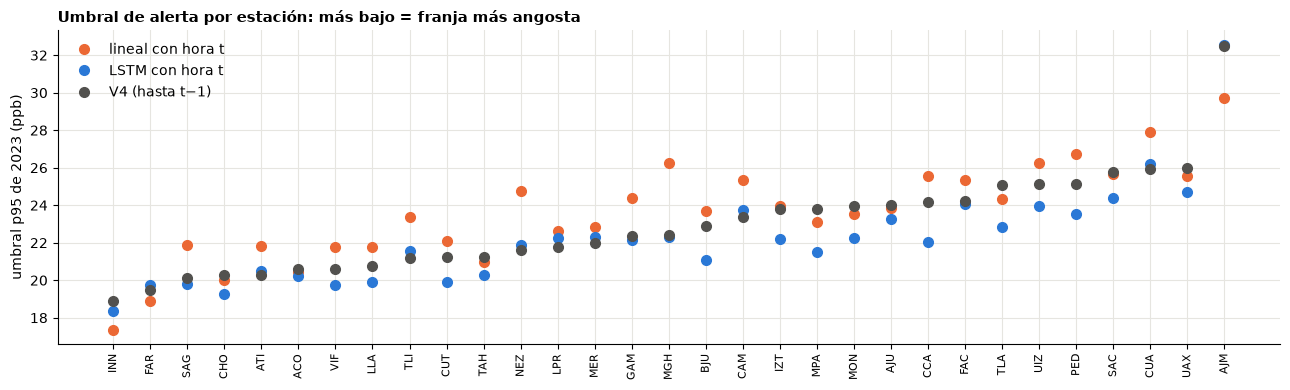

α elegido (lineal_t): {300.0: 2, 1000.0: 22, 3000.0: 7}
E elegido (lstm_t): {1: 8, 2: 10, 3: 2, 4: 2, 6: 3, 7: 1, 9: 1, 16: 1, 17: 1, 19: 1, 21: 1}


In [3]:
def calibracion(fam):
    filas = []
    base = FAM[fam] / 'estaciones'
    for obj in m.ESTACIONES:
        c = base / obj / 'calibracion_2023.csv.gz'
        if not c.exists():
            continue
        cal = pd.read_csv(c)
        cfg = json.loads((base / obj / 'configuracion.json').read_text())
        filas.append(dict(familia=fam, estacion=obj, clasificacion=CLASES[obj],
                          umbral=float((base / obj / 'umbral_p95_cal2023.txt').read_text()),
                          mae=cal.residuo_ppb.abs().mean(), mae_perfil=(cal.original_ppb - cal.base_ppb).abs().mean(),
                          E=cfg.get('epoca_E'), alpha=cfg.get('alpha')))
    return pd.DataFrame(filas)

cal = pd.concat([calibracion(f) for f in FAM], ignore_index=True)
if cal.familia.nunique() > 1:
    print(cal.groupby(['familia', 'clasificacion'])[['umbral', 'mae', 'mae_perfil']].median().round(2).to_string())
    piv = cal.pivot(index='estacion', columns='familia', values='umbral')
    fig, ax = plt.subplots(figsize=(13, 4))
    orden = piv['v4'].sort_values().index
    for fam in piv.columns:
        ax.plot(range(len(orden)), piv.loc[orden, fam], marker='o', ls='none', ms=7, color=COLOR[fam], label=ETIQ[fam])
    ax.set_xticks(range(len(orden)), orden, rotation=90, fontsize=8); ax.set_ylabel('umbral p95 de 2023 (ppb)')
    ax.legend(); ax.set_title('Umbral de alerta por estación: más bajo = franja más angosta', loc='left')
    fig.tight_layout(); fig.savefig(IMG / 'umbrales.png', dpi=150); plt.show()
    if 'lineal_t' in piv:
        print('α elegido (lineal_t):', cal[cal.familia == 'lineal_t'].alpha.value_counts().sort_index().to_dict())
    if 'lstm_t' in piv:
        print('E elegido (lstm_t):', cal[cal.familia == 'lstm_t'].E.value_counts().sort_index().to_dict())
else:
    print('Aún no hay modelos de las variantes.')

## 3. Sin ataques: falsas alarmas en la prueba

Recuerda: el umbral se fija para que en 2023 suene en 5 % de las lecturas limpias. En los
años de prueba cada familia puede desviarse distinto.

In [4]:
fams = disponibles('metricas_limpias.csv')
if len(fams) > 1:
    filas = []
    for fam in fams:
        L = leer(fam, 'metricas_limpias.csv')
        for (anio, cl), g in L.groupby(['anio', 'clasificacion']):
            filas.append(dict(familia=fam, anio=anio, grupo=cl, mae_mediana=g.mae.median(),
                              fpr_micro_pct=100 * g.falsas_alarmas.sum() / g.n.sum()))
    print(pd.DataFrame(filas).pivot_table(index=['anio', 'grupo'], columns='familia',
                                          values=['fpr_micro_pct', 'mae_mediana']).round(2).to_string())
else:
    print('Falta la etapa «evaluar» del script.')

                            fpr_micro_pct              mae_mediana             
familia                          lineal_t lstm_t    v4    lineal_t lstm_t    v4
anio grupo                                                                     
2024 baja_representatividad          6.42   7.89  7.39        8.73   8.79  8.91
     principal                       5.89   7.17  7.02        8.78   8.46  8.55
2025 baja_representatividad          7.63   7.01  7.78        8.71   8.70  8.85
     principal                       6.56   7.43  7.22        9.07   8.80  8.82
2026 baja_representatividad          5.97   4.67  6.14        8.40   7.61  8.25
     principal                       6.01   6.07  6.62        9.15   8.47  8.94


## 4. Un mensaje atacado (muestra pareada al 5 %)

Mismo plan de ataque para las tres familias. Se muestran recall (ataques atrapados) y,
al lado, precisión y falsas alarmas: **un recall mayor sólo es mejora si las falsas
alarmas no suben**.

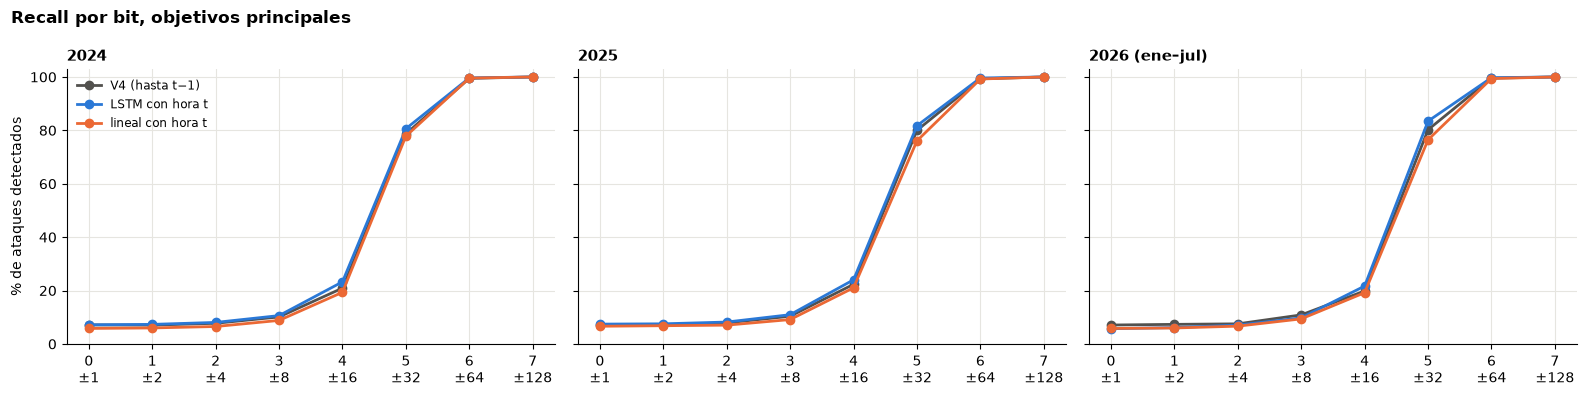

         fpr_micro_pct             precision_micro_pct              recall_micro_pct              
familia       lineal_t lstm_t   v4            lineal_t lstm_t    v4         lineal_t lstm_t     v4
anio bit                                                                                          
2024 0             5.9    7.2  7.0                 4.9    4.9   5.0              5.8    7.2    7.1
     1             5.9    7.2  7.0                 5.0    5.0   5.0              6.0    7.3    7.0
     2             5.9    7.2  7.0                 5.4    5.5   5.4              6.5    8.1    7.7
     3             5.9    7.2  7.0                 7.2    7.1   7.0              8.8   10.6   10.1
     4             5.9    7.2  7.0                14.6   14.4  13.4             19.3   23.3   20.9
     5             5.9    7.2  7.0                40.7   36.8  36.8             77.8   80.6   78.7
     6             5.9    7.2  7.0                46.7   41.9  42.4             99.6   99.6   99.5
     7    

In [5]:
fams = disponibles('metricas_pareadas_agregadas.csv')
if len(fams) > 1:
    A = pd.concat([leer(f, 'metricas_pareadas_agregadas.csv').assign(familia=f) for f in fams])
    A = A[A.grupo == 'principal']
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, anio in zip(axes, [2024, 2025, 2026]):
        for fam in fams:
            g = A[(A.familia == fam) & (A.anio == anio)]
            ax.plot(g.bit, g.recall_micro_pct, marker='o', color=COLOR[fam], label=ETIQ[fam])
        ax.set_title(f'{anio}' + (' (ene–jul)' if anio == 2026 else ''), loc='left')
        ax.set_xticks(range(8), [f'{b}\n±{2**b}' for b in range(8)]); ax.set_ylim(0, 103)
    axes[0].set_ylabel('% de ataques detectados'); axes[0].legend(fontsize=8.5)
    fig.suptitle('Recall por bit, objetivos principales', x=0.01, ha='left', fontweight='bold')
    fig.tight_layout(); fig.savefig(IMG / 'recall_un_mensaje.png', dpi=150); plt.show()
    print(A.pivot_table(index=['anio', 'bit'], columns='familia',
                        values=['recall_micro_pct', 'precision_micro_pct', 'fpr_micro_pct']).round(1).to_string())
else:
    print('Falta la etapa «evaluar» del script.')

## 5. Daño que se escapa (barrido) y desactivaciones

% de días con alguna oportunidad de daño que pasaría **sin alerta**. Para las
desactivaciones, el denominador son los días con excedencia real.

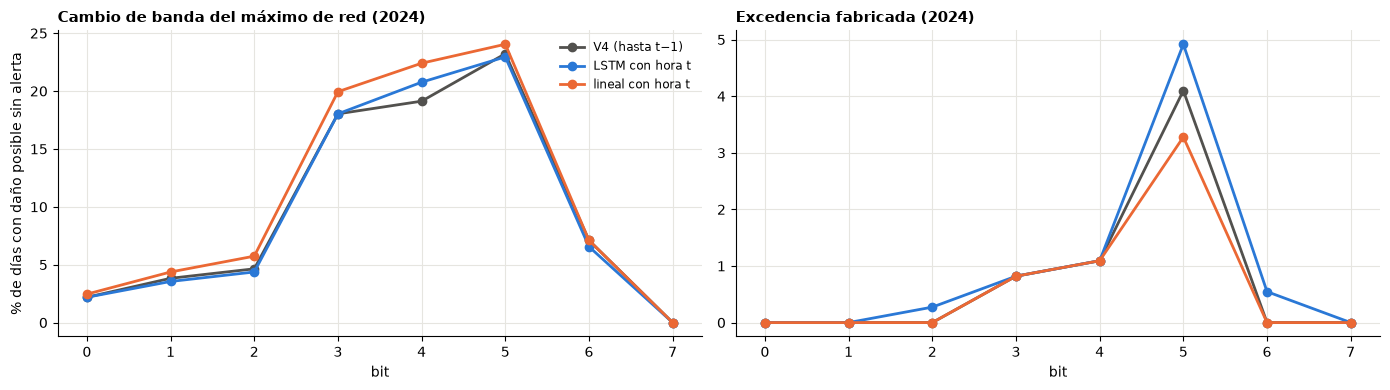

Desactivaciones (días):
 familia  anio  dias_con_excedencia  ocultables  ocultables_sin_alerta
      v4  2024                   17           3                      2
      v4  2025                    6           3                      2
      v4  2026                    9           2                      0
  lstm_t  2024                   17           3                      2
  lstm_t  2025                    6           3                      3
  lstm_t  2026                    9           2                      1
lineal_t  2024                   17           3                      2
lineal_t  2025                    6           3                      2
lineal_t  2026                    9           2                      1


In [6]:
fams = disponibles('resumen_dano_dias.csv')
if len(fams) > 1:
    D = pd.concat([leer(f, 'resumen_dano_dias.csv').assign(familia=f) for f in fams])
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, tipo, tit in zip(axes, ['cambio_banda_red', 'falsa_fase1'],
                             ['Cambio de banda del máximo de red (2024)', 'Excedencia fabricada (2024)']):
        for fam in fams:
            g = D[(D.familia == fam) & (D.anio == 2024) & (D.tipo_dano == tipo)]
            ax.plot(g.bit, g.pct_dias_dano_no_detectado, marker='o', color=COLOR[fam], label=ETIQ[fam])
        ax.set_title(tit, loc='left'); ax.set_xticks(range(8)); ax.set_xlabel('bit')
    axes[0].set_ylabel('% de días con daño posible sin alerta'); axes[0].legend(fontsize=8.5)
    fig.tight_layout(); fig.savefig(IMG / 'dano_no_detectado.png', dpi=150); plt.show()
    filas = []
    for fam in fams:
        for anio in [2024, 2025, 2026]:
            f = FAM[fam] / f'eventos_dano/eventos_{anio}.parquet'
            if not f.exists():
                continue
            ev = pd.read_parquet(f); an = ev[ev.anulada_fase1]
            exc = int(D[(D.familia == fam) & (D.anio == anio)].dias_con_excedencia_original.iat[0])
            filas.append(dict(familia=fam, anio=anio, dias_con_excedencia=exc, ocultables=an.fecha.nunique(),
                              ocultables_sin_alerta=an[an.evaluable & ~an.detectado].fecha.nunique()))
    print('Desactivaciones (días):')
    print(pd.DataFrame(filas).to_string(index=False))
else:
    print('Falta la etapa «evaluar» del script.')

## 6. Atacante simultáneo: el mismo bit en todas las estaciones a la vez

Aquí se mide si la variante contemporánea es **frágil** cuando las vecinas también están
atacadas. Si su recall cae mucho más que el del V4, la ganancia del punto 4 depende del
supuesto de un solo nodo comprometido.

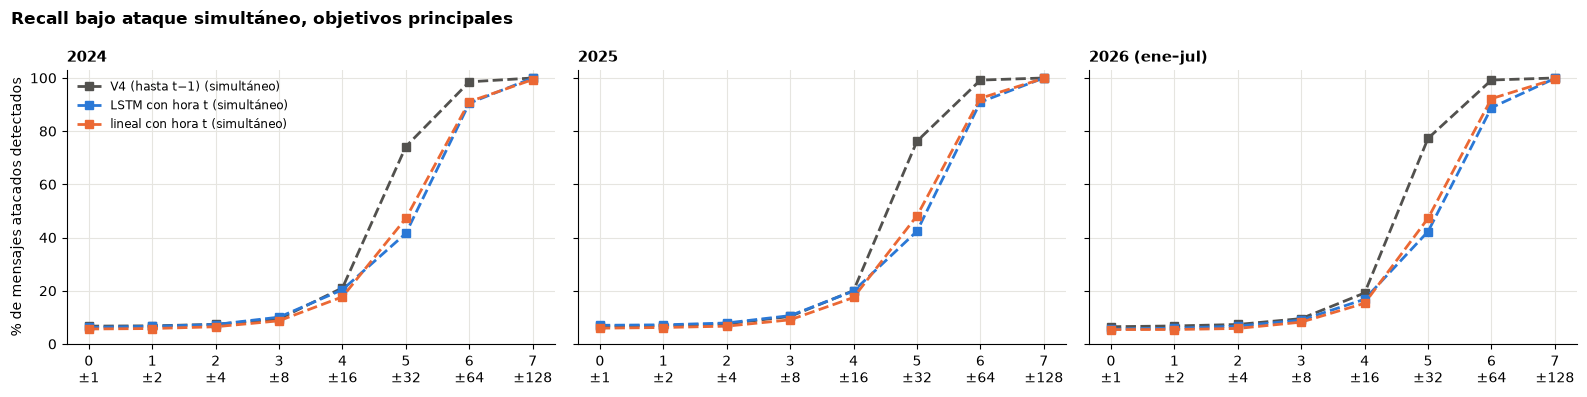

         fpr_micro_pct              precision_micro_pct              recall_micro_pct              
familia       lineal_t lstm_t    v4            lineal_t lstm_t    v4         lineal_t lstm_t     v4
anio bit                                                                                           
2024 0             5.9    7.2   7.0                 4.8    4.4   4.8              5.6    6.3    6.7
     1             5.9    7.2   7.0                 5.0    4.6   4.9              5.8    6.6    6.8
     2             5.9    7.2   7.1                 5.5    5.1   5.3              6.5    7.3    7.4
     3             5.9    7.3   7.1                 7.3    6.9   6.6              8.7   10.1    9.4
     4             5.9    7.3   7.2                13.7   12.9  13.5             17.7   20.4   21.1
     5             6.1    7.5   8.4                29.2   22.7  32.1             47.2   41.6   74.2
     6             6.5    8.6  11.1                42.7   36.0  32.1             91.1   90.5   98.5


In [7]:
f = C1 / 'simultaneo/metricas_simultaneo_agregadas.csv'
if f.exists():
    S = pd.read_csv(f); S = S[S.grupo == 'principal']
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, anio in zip(axes, [2024, 2025, 2026]):
        for fam in ['v4', 'lstm_t', 'lineal_t']:
            g = S[(S.familia == fam) & (S.anio == anio)]
            ax.plot(g.bit, g.recall_micro_pct, marker='s', ls='--', color=COLOR[fam], label=ETIQ[fam] + ' (simultáneo)')
        ax.set_title(f'{anio}' + (' (ene–jul)' if anio == 2026 else ''), loc='left')
        ax.set_xticks(range(8), [f'{b}\n±{2**b}' for b in range(8)]); ax.set_ylim(0, 103)
    axes[0].set_ylabel('% de mensajes atacados detectados'); axes[0].legend(fontsize=8.5)
    fig.suptitle('Recall bajo ataque simultáneo, objetivos principales', x=0.01, ha='left', fontweight='bold')
    fig.tight_layout(); fig.savefig(IMG / 'recall_simultaneo.png', dpi=150); plt.show()
    print(S.pivot_table(index=['anio', 'bit'], columns='familia',
                        values=['recall_micro_pct', 'precision_micro_pct', 'fpr_micro_pct']).round(1).to_string())
else:
    print('Falta la etapa «simultaneo» del script.')

## 7. Notas

Escribe aquí la interpretación cuando estén los resultados. Recordatorio de reglas del
protocolo: comparar siempre recall con FPR/precisión; desactivaciones condicionadas a días
con excedencia; nada de esto se usa para ajustar α, E, umbrales o estaciones.

#### 2026-10-04 — Primera ejecución completa

- **Qué se hizo:** `experiments/contemporaneo/ejecutar.py` completo (22:05–22:33, 27.9 min),
  lanzado por Claude a petición del tesista. 31 `lstm_t` y 31 `lineal_t` entrenados sin
  errores; verificación de CCA reproducible en ambas familias (E/α, pesos o coeficientes,
  p95 y predicciones idénticos). V4 cargado de disco, sin cambios.
- **Resultados:**
- **Calibración 2023 (principales, mediana):** MAE V4 7.78 · `lstm_t` 7.62 (−2 %) ·
  `lineal_t` 8.38 ppb; umbral p95 22.65 · 22.18 · 23.79 ppb. α elegido: 1000 en 22
  estaciones, 3000 en 7 y 300 en 2 (ninguno en el borde de la rejilla ampliada). E de
  `lstm_t`: 1–2 en 18 de 31.
- **Limpio en prueba (FPR micro, principales):** 2024: V4 7.0 · `lstm_t` 7.2 ·
  `lineal_t` 5.9 %; 2025: 7.2 · 7.4 · 6.6 %; 2026: 6.6 · 6.1 · 6.0 %.
- **Un mensaje, muestra pareada (principales, 2024):** bit 4 → 20.9 · 23.3 · 19.3 %;
  bit 5 → 78.7 · 80.6 · 77.8 %. 2025 y 2026 en la misma línea: `lstm_t` +1 a +3 puntos.
- **Desactivaciones sin alerta / días con excedencia:** V4 2/17, 2/6, 0/9; `lstm_t` 2/17,
  3/6, 1/9; `lineal_t` 2/17, 2/6, 1/9. Ninguna variante mejora.
- **Atacante simultáneo (bit 5, principales):** V4 74.2 / 76.2 / 77.3 % (2024/25/26);
  `lstm_t` 41.6 / 42.4 / 42.3 %; `lineal_t` 47.2 / 48.2 / 47.2 %. Bit 6: V4 98.5–99.2 %,
  variantes 88.8–92.4 %. El V4 bajo ataque simultáneo eleva sus falsas alarmas con bits
  grandes (11 % bit 6, 18 % bit 7 en 2024): las horas atacadas contaminan ventanas y
  perfiles de horas posteriores.

- **Interpretación:** la información de la misma hora reduce poco el error (la ganancia de
  la exploración, medida sólo en horas con 8 vecinas completas, no se sostiene en todas
  las horas) y mejora la detección de un mensaje en 1–3 puntos, pero hace al detector
  **mucho más frágil** si el atacante voltea el mismo bit en todas las estaciones a la
  vez, algo posible para un atacante entre NS y AS. El lineal con la hora t queda por
  debajo del V4 en error: el LSTM con contexto pasado sí aporta frente a una línea base
  simple.
- **Decisión:** resultado negativo para J1. Se conserva el V4 (contexto pasado) como
  detector de referencia. Nada de esto modifica umbrales, E ni estaciones.

#### Plantilla

```
#### AAAA-MM-DD — título
- Qué se hizo:
- Resultados (calibración, limpio, un mensaje, daño, simultáneo):
- Interpretación:
- Decisiones / pendientes:
```